Joyce Wang
- 11/17/2025
- Edited 11/21/2025 with input from Lucas, and updated DEG portion.
- Edited 11/25/2025 to add notes and work on other visualizations.
- Edited 12/14/2025 to fix up "Normalization" section, add in "Cleaning up labels" section, update DEG section.
- Edited 12/16/2025 to create three separate notebooks for each gene set, and to begin visualizing heatmaps and gene rank vs. enrichment score plots.
- Edited 01/10/2026 to adjust heatmaps and create separate gene rank vs. enrichment score plots. Notes also kept on a Google Doc.

Referred to: 
- Tutorial: https://nbisweden.github.io/workshop-scRNAseq/labs/scanpy/scanpy_05_dge.html#meta-dge_gsa
- GSEApy documentation with tutorial: https://gseapy.readthedocs.io/en/latest/gseapy_example.html#Assign-prerank()-with
- GSEApy Github: https://github.com/zqfang/GSEApy
- General information about gene set enrichment and pathway analysis for single-cell: https://www.sc-best-practices.org/conditions/gsea_pathway.html

# Gene Set Enrichment Analysis with GSEApy: Intro

*"We can perform gene set enrichment analysis (GSEA), which scores ranked genes list (usually based on fold changes) and computes permutation test to check if a particular gene set is more present in the Up-regulated genes, among the DOWN_regulated genes or not differentially regulated..."*

In [1]:
# pip install gseapy

In [2]:
# Core libraries
import hisepy
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

from gseapy import dotplot

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


# Load in data

In [3]:
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [4]:
# creating a list
adata_list = []

# looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [5]:
# using anndata to concatenate: code chunk from Scanpy tutorial

# combine multiple anndata objects and adds a "sample" column telling you which dataset each cell came from; aka, which DRUG NAME each cell was treated with!
adata = ad.concat(adata_list, label="sample")

# make sure all observations are unique
adata.obs_names_make_unique()

# filter out CD8aa because there aren't enough!
adata = adata[adata.obs.AIFI_L2 != "CD8aa"]

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [6]:
# len(adata_list) for how many files are in the list: 18, for 8 drugs with 2 formulas each and 2 controls
print(f"Length of adata_list is {len(adata_list)}")

adata

Length of adata_list is 18


View of AnnData object with n_obs × n_vars = 449975 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2', 'sample'
    obsm: 'X_pca', 'X_umap'

**The data contains 25,000 cells per sample, 18 samples (for 8 drugs with 2 formulas each and 2 controls), 450,000 observations (total cells), and 1,916 measured genes.**

# Cleaning up labels

Removing accession numbers/IDs from the drug names for the sake of presentation figures.

In [7]:
import re

unique_drug_names = adata.obs['drug_name'].unique()

def clean_name(name):
    name = re.sub(' \\(.*\\) ', ' ', name)
    name = re.sub(' \\(.*\\)$', '', name)
    return name

# for name in unique_drug_names:
    # print(clean_name(name))

adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)

# .map(clean_mapping)

/tmp/ipykernel_370/1385670149.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clean_drug_name'] = adata.obs['drug_name'].copy().apply(clean_name)


# Normalization

In [8]:
# Preserve raw counts of [cells x genes] by making a copy of adata.X and calling it the "counts" layer
adata.layers["counts"] = adata.X.copy()

# Normalize counts of [cells x genes] adata.X (rescale each cell to a specific library size)
sc.pp.normalize_total(adata, target_sum = 1e4)

# Apply log-transform to adata.X, so it's normalized and logged
sc.pp.log1p(adata)

# Make a copy of adata.X, call it the "log_transformed" layer, which is normalized and logged
adata.layers["log_transformed"] = adata.X.copy()

# DEGs

In [9]:
# making a dictionary of subsetted data where the key is the cell type, and the value is the anndata object with DE results inside
subsets_cells = {}

for cell_type in adata.obs['AIFI_L2'].unique(): # looping through cell types
    # print(f'current cell type is {cell_type}')
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()
    # run differential expression
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "clean_drug_name", # drug treatments compared against the DMSO negative control
        reference = "DMSO Control",
        method = "wilcoxon", # Scanpy's Wilcoxon rank-sum test
        layer = "log_transformed" # log-normalized expression
    )
    subsets_cells[cell_type] = cell_type_subset # store each cell type-specific DE result in a dictionary

# print(subsets_cells)

# get_rank

In [10]:
# for cell_type, subset_cell in subsets_cells.items():    
    # print(cell_type)
    # sc.pl.rank_genes_groups_dotplot(subset_cell, groupby="clean_drug_name", n_genes=5)

Trying to make sense of the above dot plots, it at first seemed like the columns are repeating information since the reference is only ever the DMSO control. It seems like this is actually picking out the top 5 differentially expressed genes against the reference for each treatment, and is *then* showing the levels those genes are expressed across **all** of the treatments.

... More DEG analyses by Sean.

# Gene Set Enrichment Analysis using GSEApy

**Note: We are looking at *each* drug (`drug_name`) vs. DMSO neg. control (the reference) for *each* cell type (AIFI_L2)**.

Why run GSEA after DEG?: “On the aggregate level, like running GSEA after differential gene expression tests, we can check for enrichment of pathways for the whole set of cells we used to generate the DEGs, which is quite useful.”

# Gene set `KEGG_2019_Human`

## Extract DEG results into ranked genes using `prerank()`

We need a table with all DEGs and their log foldchanges. However, many lowly expressed genes will have high foldchanges and just contribue noise, so also filter for expression in enough cells.

`sc.get.rank_genes_groups_df(subset_cell, group=drug)` returns a nice table with `names` (DEG names), `scores`, `logfoldchanges`, `pvals_adj`, etc...

For each drug vs. DMSO, extract a ranked gene list with GENE and RANK_METRIC.

In [11]:
### Add a dict to store results
gsea_res = {}

for cell_type, subset_cell in subsets_cells.items():
    ### Nested dict to store each drug
    gsea_res[cell_type] = {}
    
    # adapted from tutorial linked above: calculate_qc_metrics will calculate number of cells per gene
    sc.pp.calculate_qc_metrics(subset_cell, percent_top=None, log1p=False, inplace=True)

    # list of drug "groups"
    deg = subset_cell.uns["rank_genes_groups"]
    drugs = deg["names"].dtype.names

    for drug in drugs:
        if drug == "DMSO Control":
            continue # skip reference condition

        # adapted from tutorial linked above: extract ranked genes (names + logFC)
        gene_rank = sc.get.rank_genes_groups_df(
            subset_cell,
            group = drug,
            key = 'rank_genes_groups')[['names','logfoldchanges']]
    
        # adapted from tutorial above: Filtering out the gene sets with low number of genes -> filter for genes expressed in at least 30 cells
        gene_rank = gene_rank[gene_rank["names"].isin(
            subset_cell.var_names[subset_cell.var.n_cells_by_counts > 30]
        )]

        ### Sort the genes from high to low fold changes
        gene_rank = gene_rank.sort_values('logfoldchanges', ascending = False)
        
        # adapted from multiple tutorials: Run prerank GSEA directly with gp.prerank()
        pre_res = gp.prerank(
            rnk = gene_rank,
            gene_sets = "KEGG_2019_Human", # Could also download gene sets from: Msigdb hallmark gene sets, Reactome, etc...
            outdir = None, # don't write to disk
            verbose = False # make True to see what's going on behind the scenes
        )
        
        ### Store the output in our nested dict
        gsea_res[cell_type][drug] = pre_res

2026-01-13 12:03:38,505 [WARNING] Duplicated values found in preranked stats: 0.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-13 12:03:42,729 [WARNING] Duplicated values found in preranked stats: 0.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-13 12:03:45,246 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-13 12:03:48,875 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-13 12:03:56,609 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-13 12:03:57,110 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be

## Visualize GSEA plots with GSEApy

- Visualize it using gseaplot
- Make sure that ofname is not None, if you want to save your figure to the disk

## View results for each cell type and drug, in a table:

In [12]:
# View results for each cell type and drug name:

# Note: CD4 Naive cell type and IL6 Control shown here: expect JAK/STAT pathway to be enriched b/c of IL-6 stimulating it in the control
pre_res = gsea_res['CD4 Naive']['IL6 Control']
pre_res.res2d.sort_values('FDR q-val').head(10)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Complement and coagulation cascades,0.831964,1.845261,0.001558,0.213076,0.142,4/21,2.63%,PROS1;MASP2;F5;C2
6,prerank,JAK-STAT signaling pathway,0.665399,1.620054,0.009539,0.567724,0.83,15/67,7.90%,IL13RA1;IL6;IL2RB;IL2RA;IL21;MYC;IL7;STAT3;IL1...
5,prerank,Insulin resistance,0.71754,1.634995,0.040717,0.577751,0.798,5/31,6.68%,IL6;STAT3;PTPN1;PRKCQ;TRIB3
9,prerank,Staphylococcus aureus infection,0.754212,1.577519,0.093502,0.629959,0.895,2/16,2.63%,MASP2;C2
10,prerank,Cytosolic DNA-sensing pathway,0.727203,1.558711,0.079032,0.647771,0.908,4/22,10.48%,IL6;AIM2;POLR1C;IRF7
7,prerank,Hematopoietic cell lineage,0.658664,1.588315,0.044248,0.650661,0.875,6/45,4.11%,IL6;MS4A1;IL2RA;IL7;ITGA1;ITGA6
11,prerank,Non-alcoholic fatty liver disease (NAFLD),0.65849,1.538826,0.082524,0.672578,0.927,2/35,1.86%,IL6;FAS
3,prerank,Bacterial invasion of epithelial cells,0.760466,1.657625,0.064263,0.691994,0.755,1/19,0.51%,DNM1
4,prerank,Hypertrophic cardiomyopathy (HCM),0.745256,1.635134,0.056162,0.6931,0.798,5/21,8.55%,IL6;ITGA1;ITGA6;TGFB2;ITGA2
12,prerank,Pathways in cancer,0.551615,1.498182,0.024818,0.778598,0.95,49/172,18.51%,IL13RA1;IL6;IL2RB;IL2RA;MYC;NOTCH1;FAS;IL7;SPI...


### **FDR q-vals are not good.**

- **Problem (ask YuDong):** FDR q-vals aren't great, use NOM p-val for cutoffs for now, or relax the FDR cutoffs... 
     - or use another gene set database source (Hallmark, Reactome, etc...)
- **Problem w/ FDR q-vals:** we don't have the full set of genes in the probe set (only selected ~1900 genes) --> could lead to bad FDR q-vals (not a lot of genes are being picked up, so they're not being ranked very well). This was ok'ed by Lucas; blame it on the small gene set.

## Heatmap 1) Multi-pathway visualization: Heatmap for normalized enrichment scores (NES) for each cell type, drugs x (selected) pathways.
- For each cell type:
     - NES as values
     - drug names on one axis
     - pathways on the other axis
- Across drugs, which pathways are consistently activated or suppressed in a given cell type (against the DMSO control)?
- Positive NES -> pathway activated against DMSO
- Negative NES -> pathway suppressed against DMSO

In [13]:
# Get all pathway names
kegg_pathways = pre_res.res2d["Term"].values
# print(kegg_pathways)

In [ ]:
# Select pathways of interest, related to immune responses:
selected_pathways = [
    "JAK-STAT signaling pathway",
    "TNF signaling pathway",
    "NF-kappa B signaling pathway",
    "Rheumatoid arthritis"
]

heatmap1_records = []

for cell_type, drug_dict in gsea_res.items():
    for drug, pre_res in drug_dict.items():
        res = pre_res.res2d # results in rows with columns like Term, NES, FDR q-val, etc...

        for pathway in selected_pathways:
            if pathway in res["Term"].values:
                # Extract the NES value using labels (loc); from the rows where the pathway matches, return the NES column as nes
                nes = res.loc[res["Term"] == pathway, "NES"].values[0]
            else:
                nes = float("nan")  # pathway not enriched/not present in table
                
            heatmap1_records.append({
                "cell_type": cell_type,
                "drug": drug,
                "pathway": pathway,
                "NES": nes
            })

# Create dataframe
heatmap1_nes_df = pd.DataFrame(heatmap1_records)

In [15]:
# Original heatmap before adding in annotations for NES values from -1 to 1:

# cell_types = heatmap1_nes_df["cell_type"].unique()

# # Loop through each cell type, and plot a heatmap
# for cell_type in cell_types:
    
#     # Pivot the data for this cell type
#     heatmap1_data = heatmap1_nes_df[
#         heatmap1_nes_df["cell_type"] == cell_type
#     ].pivot(
#         index="pathway",   # rows = pathways
#         columns="drug",    # columns = drugs
#         values="NES"       # values = NES
#     )

#     # Create the figure
#     plt.figure(figsize=(len(heatmap1_data.columns)*0.8, 6)) # width scales with # of drugs
    
#     sns.heatmap(
#         heatmap1_data,
#         cmap="RdBu_r",      # Red = positive NES, Blue = negative NES
#         center=0,           # Center colormap at 0
#         linewidths=0.5,
#         cbar_kws={"label": "Normalized Enrichment Score (NES)"}
#     )

#     plt.title(f"NES for selected pathways, zooming into: {cell_type}")
#     plt.ylabel("Pathway")
#     plt.xlabel("Drug")
#     plt.xticks(rotation=45, ha="right")
#     plt.tight_layout()
#     plt.show()

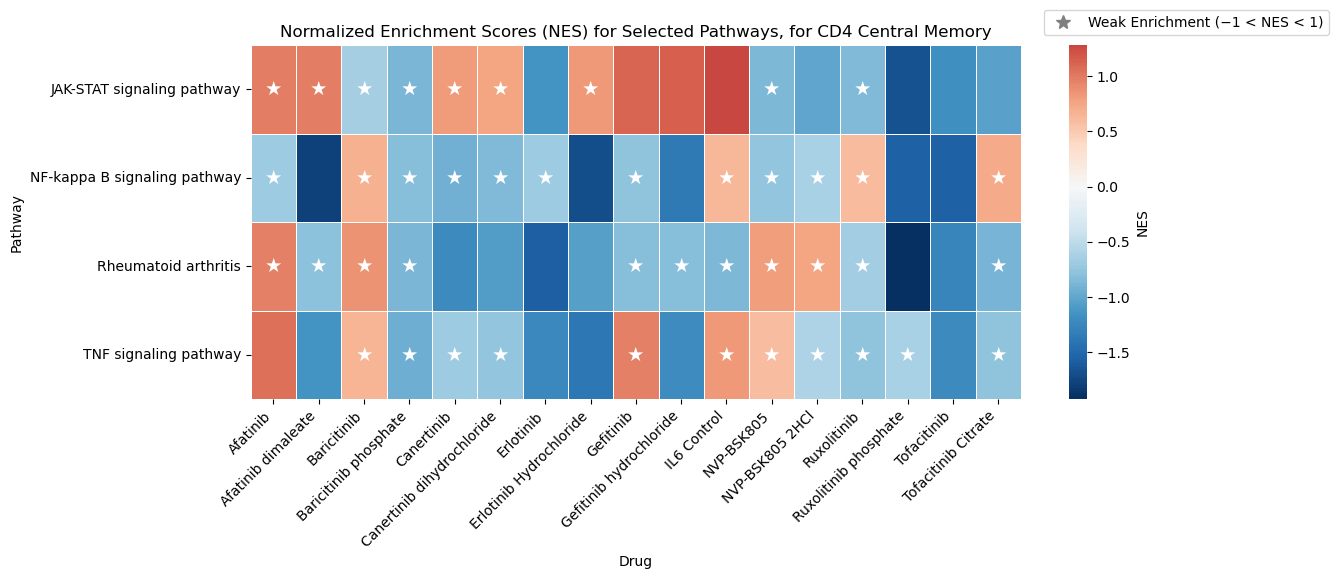

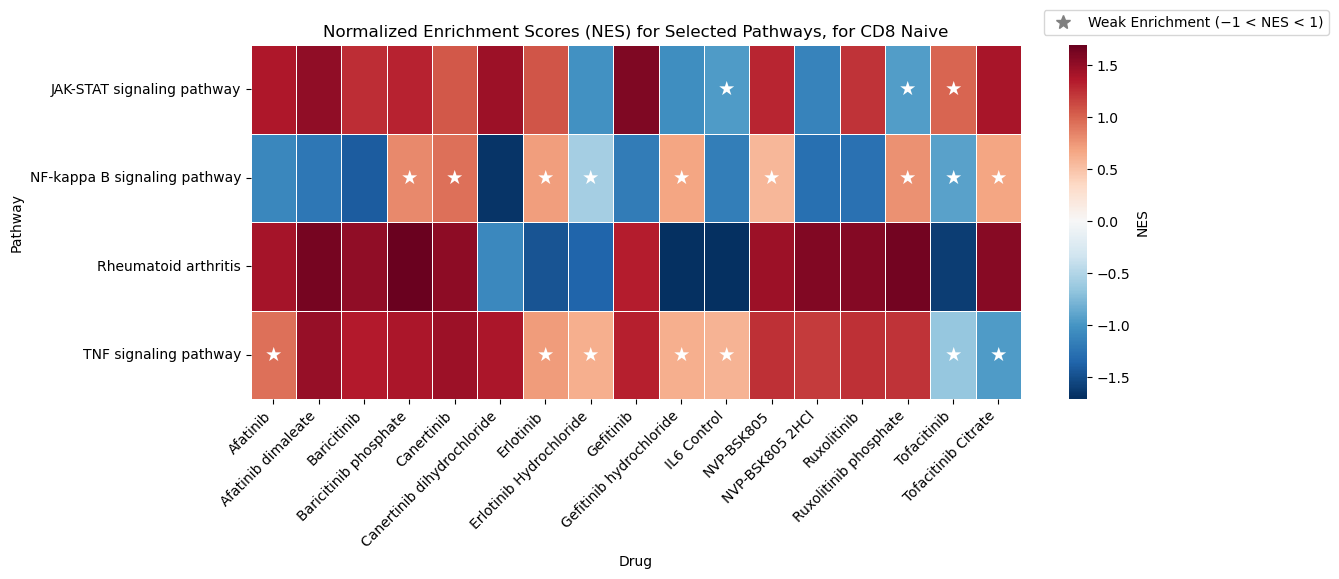

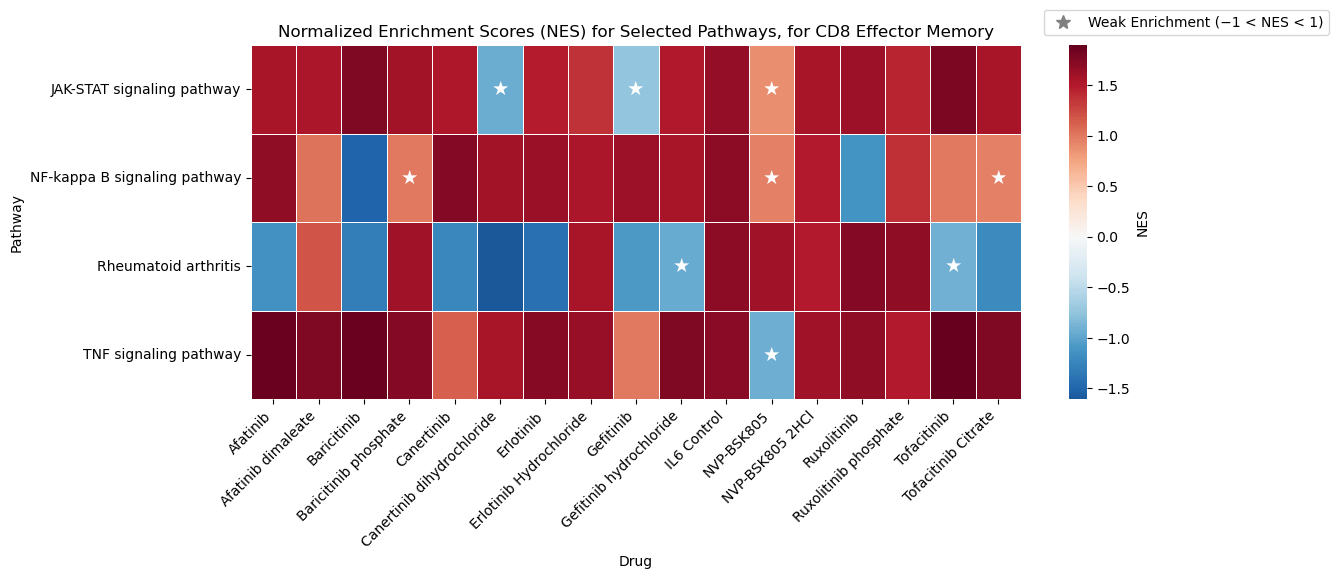

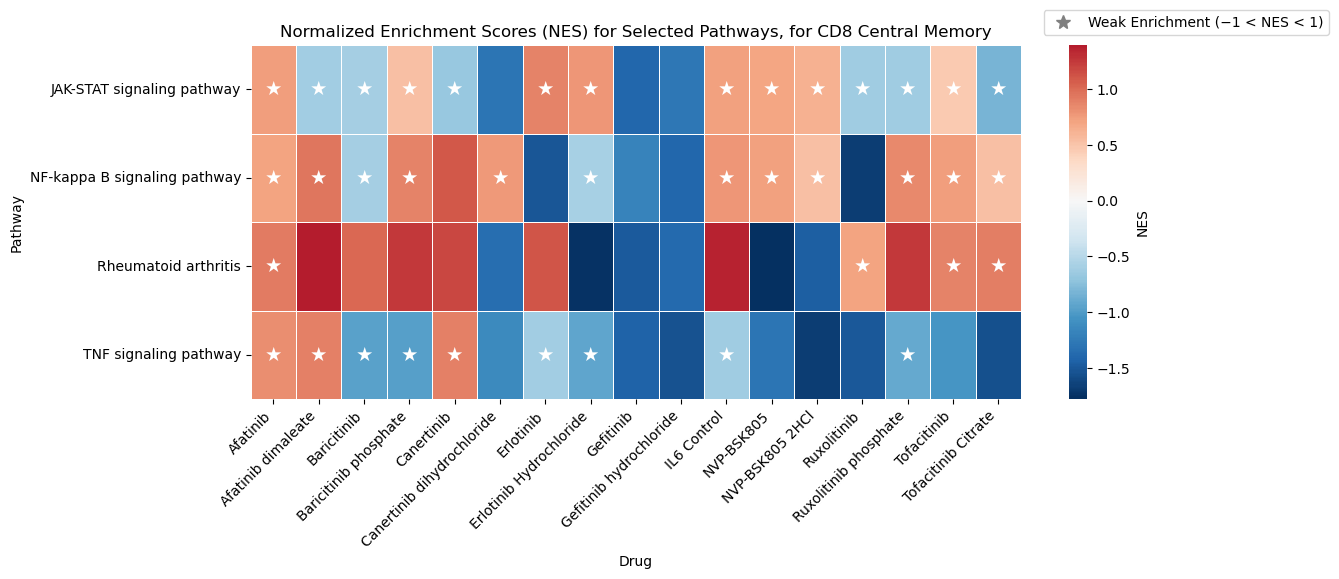

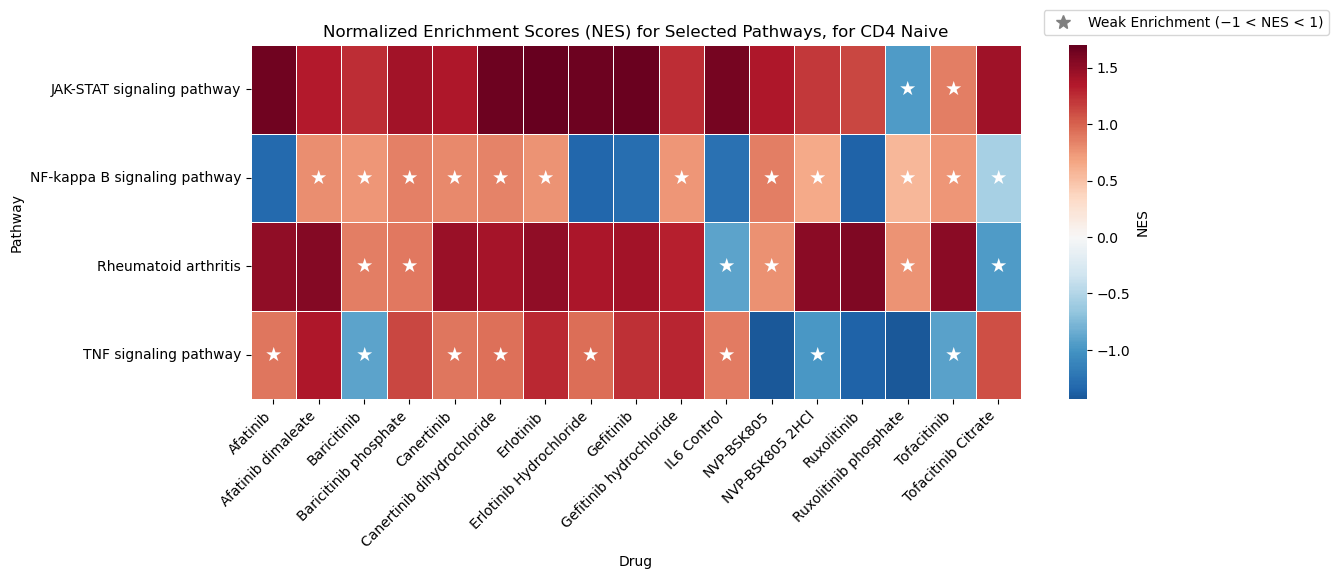

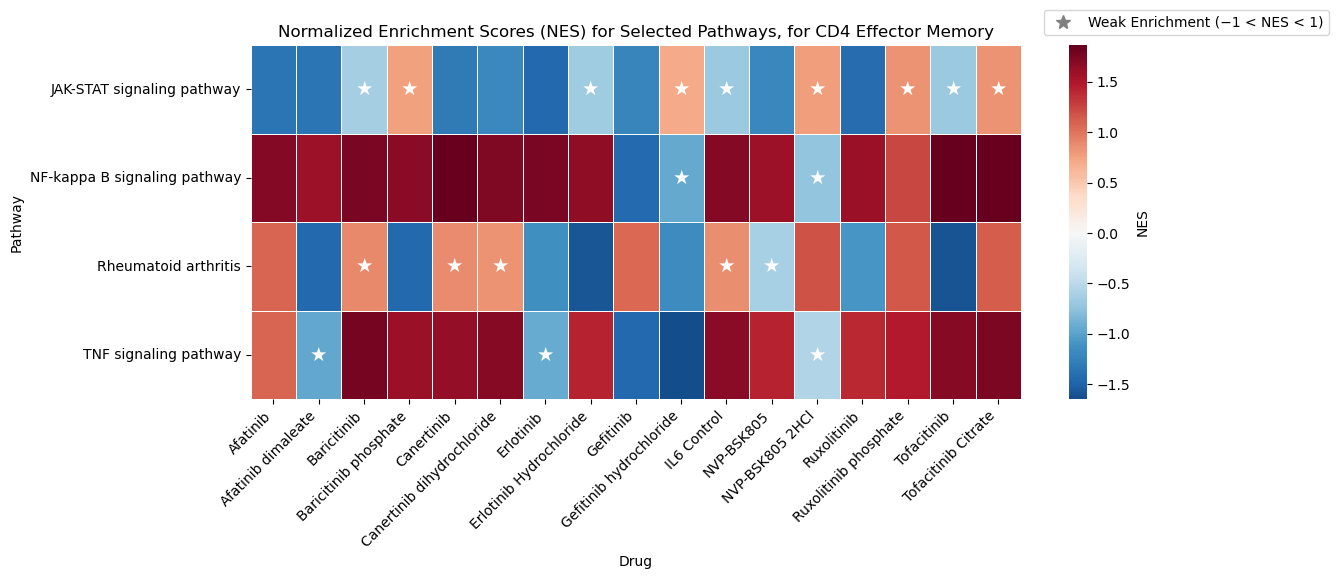

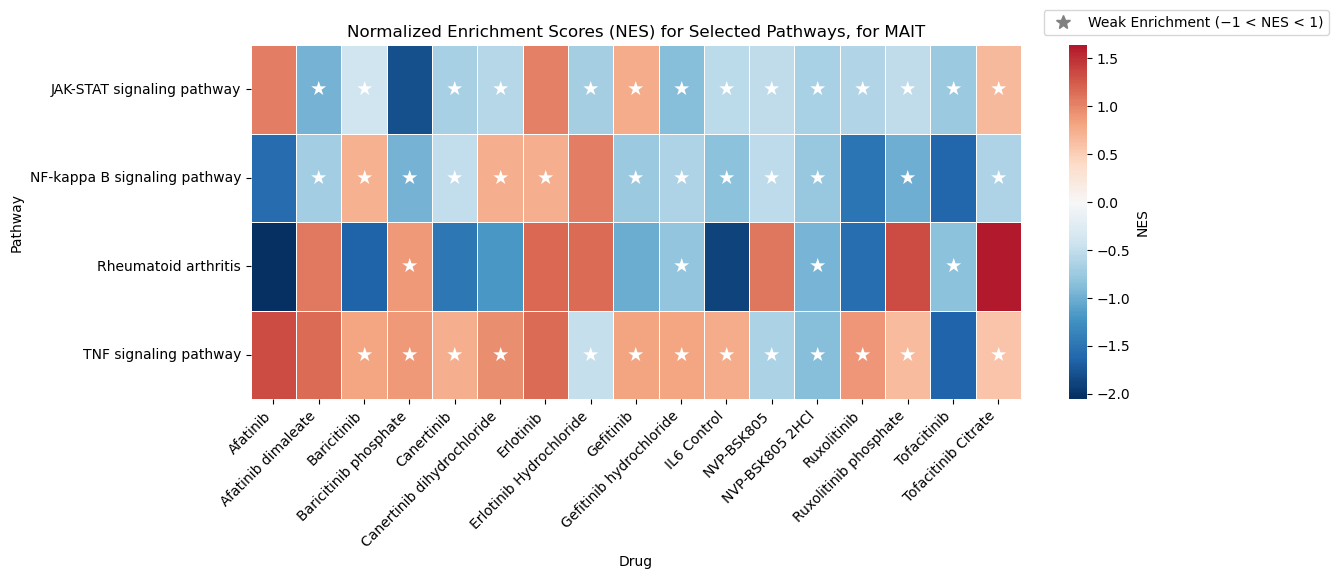

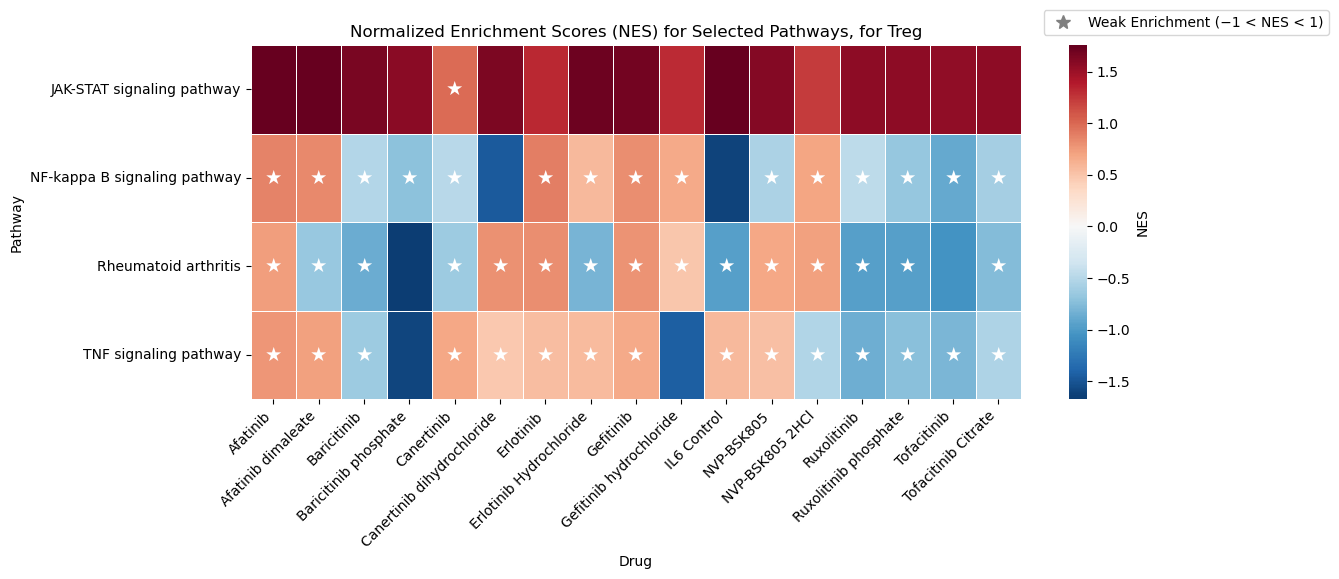

In [38]:
# starred cells for NES values from -1 to 1:

from matplotlib.lines import Line2D

cell_types = heatmap1_nes_df["cell_type"].unique()

for cell_type in cell_types:
    
    # Pivot the data for this cell type
    heatmap1_data = heatmap1_nes_df[
        heatmap1_nes_df["cell_type"] == cell_type
    ].pivot(
        index="pathway", # rows = pathways
        columns="drug", # columns = drugs
        values="NES" # values = NES
    )

    # Plot the heatmap
    plt.figure(figsize=(len(heatmap1_data.columns)*0.8, 6)) # width scales with # of drugs
    
    sns.heatmap(
        heatmap1_data,
        cmap="RdBu_r", # Red = positive NES, Blue = negative NES
        # Center colormap at 0
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "NES"},
        annot = False,
        square = False
    )

    # Annotate NES values from -1 to 1
    # loop over every cell in heatmap first
    for i, pathway in enumerate(heatmap1_data.index):
        for j, drug in enumerate(heatmap1_data.columns):
            nes_value = heatmap1_data.loc[pathway, drug] # pull out NES value for a specific cell using particular labels (loc)
            if -1 <= nes_value <= 1: # note: doesn't actually star values -1 and 1!!!
                # extract plot axes first,
                # then position the text in the center of the cell
                plt.gca().text(j + 0.5, i + 0.5, "★", ha='center', va='center', color='white', fontsize=14)

    # Add a legend explaining NES values from -1 to 1 have an asterick
    legend_elements = [
        Line2D([0], [0], marker="*", color="gray", linestyle="None", markersize=10,
        label="Weak Enrichment (−1 < NES < 1)")
    ]
    
    plt.gca().legend(handles=legend_elements,
                     loc="upper right",
                     bbox_to_anchor = (1.4, 1.1),
                     borderaxespad = 0,
                     frameon = True)

    # Fix up  the plots
    plt.title(f"Normalized Enrichment Scores (NES) for Selected Pathways, for {cell_type}")
    plt.ylabel("Pathway")
    plt.xlabel("Drug")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Heatmap 2) Single pathway visualization: Heatmap for NES for a single pathway (JAK-STAT), drugs x cell type.
- For a single pathway:
     - NES as values
     - drug names on one axis
     - cell type on the other axis
- Positive NES -> pathway activated against DMSO
- Negative NES -> pathway suppressed against DMSO

In [18]:
# Collect NES values and keep track of drug names and cell types
heatmap2_records = []

for cell_type, drug_dict in gsea_res.items():
    for drug, pre_res in drug_dict.items():
        res = pre_res.res2d # rows with columns like Term, NES, FDR q-val, etc...
        
        if "JAK-STAT signaling pathway" in res["Term"].values:
            # Extract the NES value using labels (loc); from the rows where the pathway matches, return the NES column as nes
            nes = res.loc[
                res["Term"] == "JAK-STAT signaling pathway", "NES"
            ].values[0]
        else:
            nes = float("nan")  # pathway not enriched
        
        heatmap2_records.append({
            "cell_type": cell_type,
            "drug": drug,
            "NES": nes
        })

# Create dataframe
heatmap2_nes_df = pd.DataFrame(heatmap2_records)

# Pivot the data to matrix form
heatmap2_nes_matrix = heatmap2_nes_df.pivot(
    index="cell_type",
    columns="drug",
    values="NES"
)

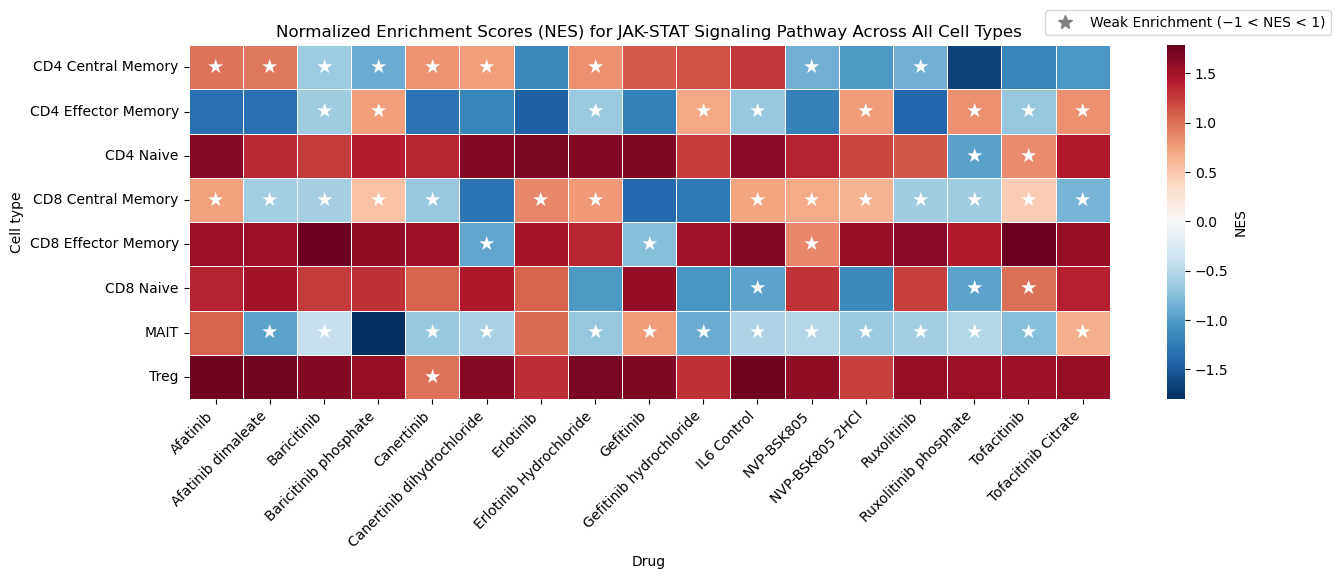

In [19]:
# Plot the heatmap
plt.figure(figsize=(len(heatmap2_nes_matrix.columns)*0.8, 6)) # width scales with # of drugs

sns.heatmap(
    heatmap2_nes_matrix,
    center=0,
    cmap="RdBu_r",
    linewidths=0.5,
    cbar_kws={"label": "NES"},
    annot = False,
    square = False
)

# Annotate NES values from -1 to 1
for i, pathway in enumerate(heatmap2_nes_matrix.index):
    for j, drug in enumerate(heatmap2_nes_matrix.columns):
        nes_value = heatmap2_nes_matrix.loc[pathway, drug]
        if -1 <= nes_value <= 1: # note: doesn't actually star values -1 and 1!!!
            plt.gca().text(j + 0.5, i + 0.5, "★", ha='center', va='center', color='white', fontsize=14)

# Add a legend explaining NES values from -1 to 1 have an asterick
legend_elements = [
    Line2D([0], [0], marker="*", color="gray", linestyle="None", markersize=10,
    label="Weak Enrichment (−1 < NES < 1)")
]

plt.gca().legend(handles=legend_elements,
                 loc="upper right",
                 bbox_to_anchor = (1.24, 1.1),
                 borderaxespad = 0,
                 frameon = True)
    
# Fix up the plot
plt.title("Normalized Enrichment Scores (NES) for JAK-STAT Signaling Pathway Across All Cell Types")
plt.ylabel("Cell type")
plt.xlabel("Drug")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# Annotate the legend for weak NES scores within the title

# plt.gca().set_title(f"Normalized Enrichment Scores (NES) for JAK-STAT Signaling Pathway Across All Cell Types\n"
         # "★ indicates weak enrichment (−1 ≤ NES ≤ 1)",
         # fontsize = 12)

## Single pathway visualization: Gene rank vs. Enrichment score plots

In [34]:
# GSEA plot for a single pathway:
terms = pre_res.res2d.Term
# axs = pre_res.plot(terms=terms[1]) # v1.0.5

# to make more control on the plot, use
# from gseapy import gseaplot
# gseaplot(rank_metric=pre_res.ranking, term=terms[0], ofname='your.plot.pdf', **pre_res.results[terms[0]])

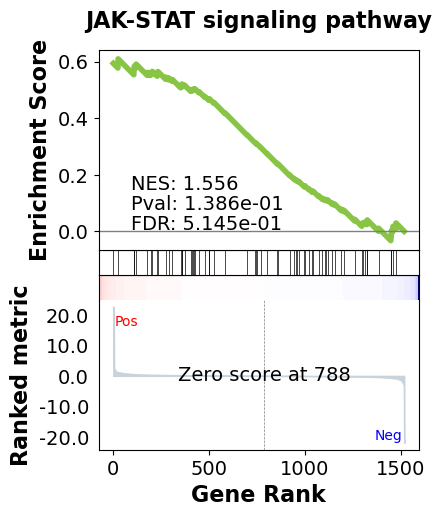

In [35]:
# GSEA plot for the JAK-STAT pathway only:
axs = pre_res.plot(terms="JAK-STAT signaling pathway")

**With so many cell types and so many drugs, this kind of plot may be too general. So let's do something different with the enrichment score plots!**

### Single pathway visualization: Gene rank vs. Enrichment score plots: zooming in on certain cell types, and comparing different treatments against the DMSO control

In [36]:
pathway = "JAK-STAT signaling pathway"

comparisons = [
    # (cell_type, treatment, label)
    ("CD4 Central Memory", "IL6 Control", ""),
    ("CD8 Effector Memory", "IL6 Control", ""),

    ("CD4 Central Memory", "Ruxolitinib", "(Strong inhibitor)"),
    ("CD8 Effector Memory", "Ruxolitinib", "(Strong inhibitor)"),

    ("CD4 Central Memory", "Baricitinib", "(Strong inhibitor)"),
    ("CD8 Effector Memory", "Baricitinib", "(Strong inhibitor)"),

    ("CD4 Central Memory", "Afatinib", "(Weak inhibitor)"),
    ("CD8 Effector Memory", "Afatinib", "(Weak inhibitor)"),
]

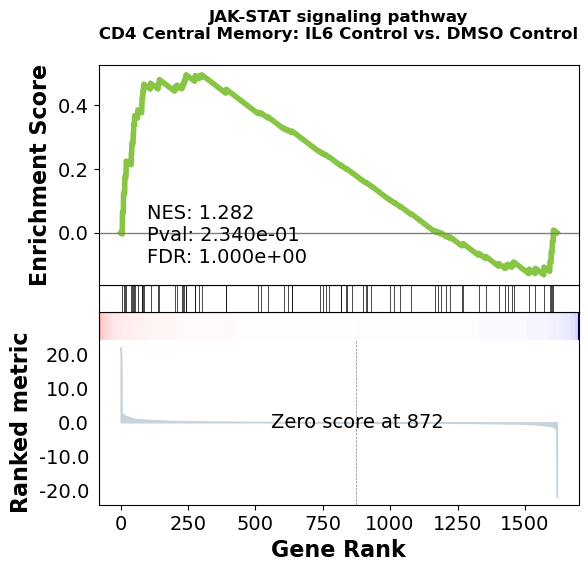

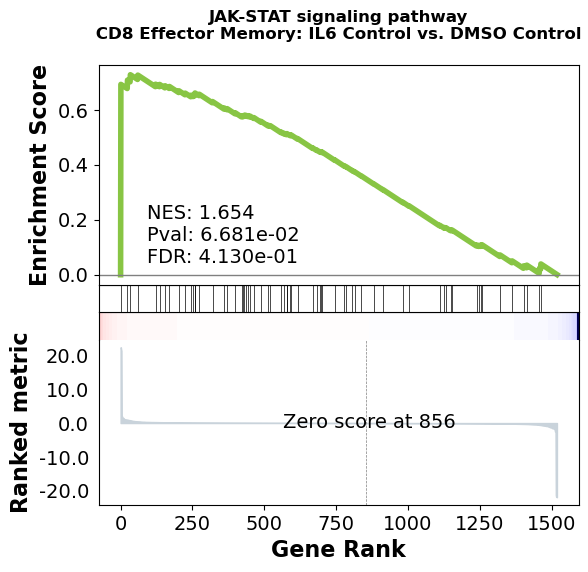

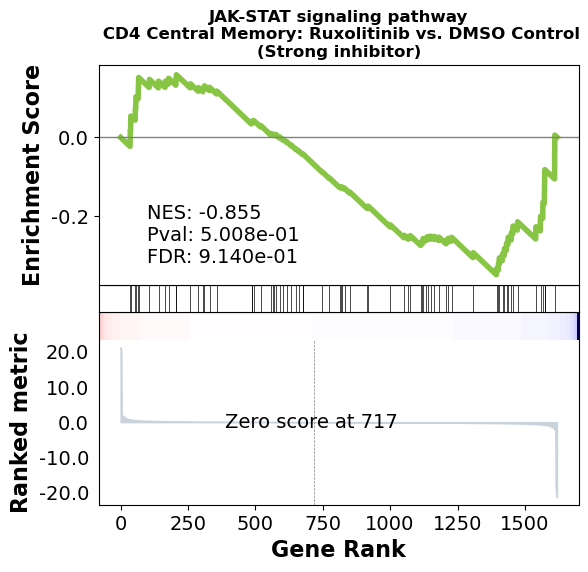

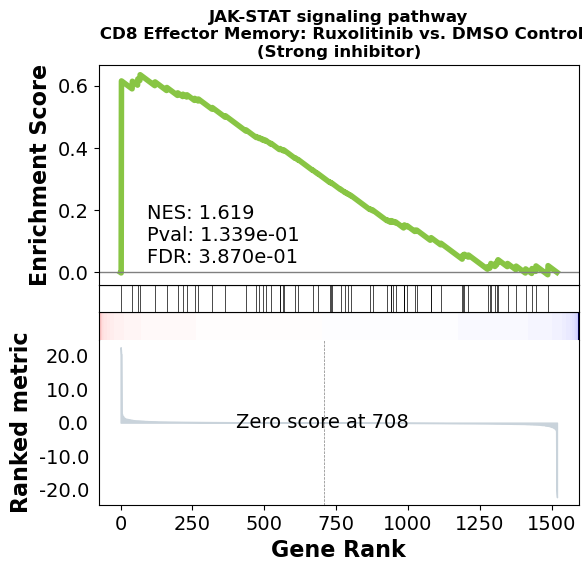

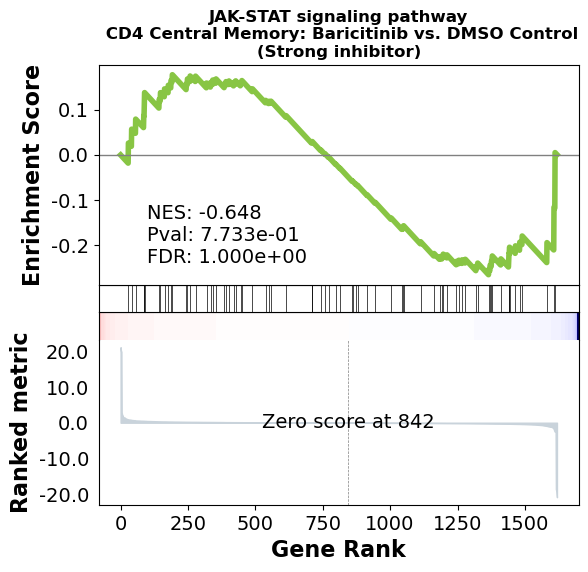

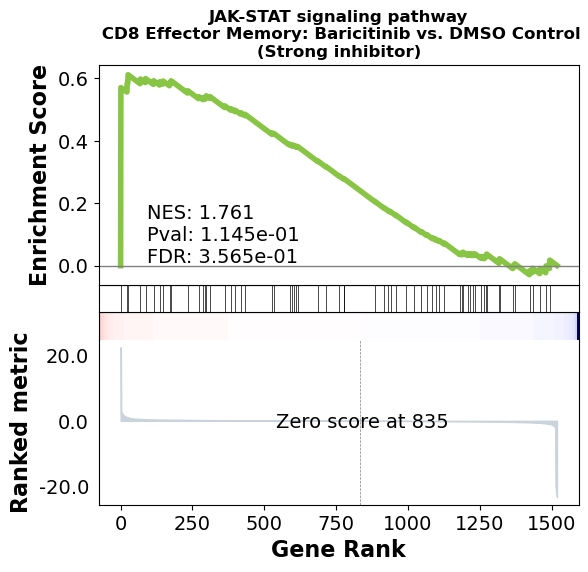

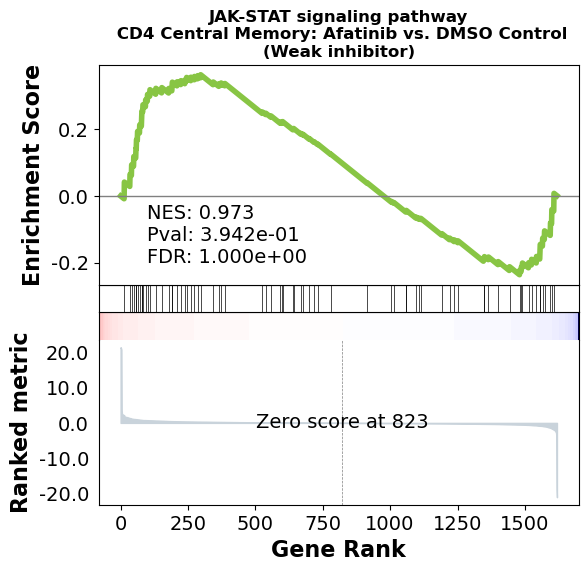

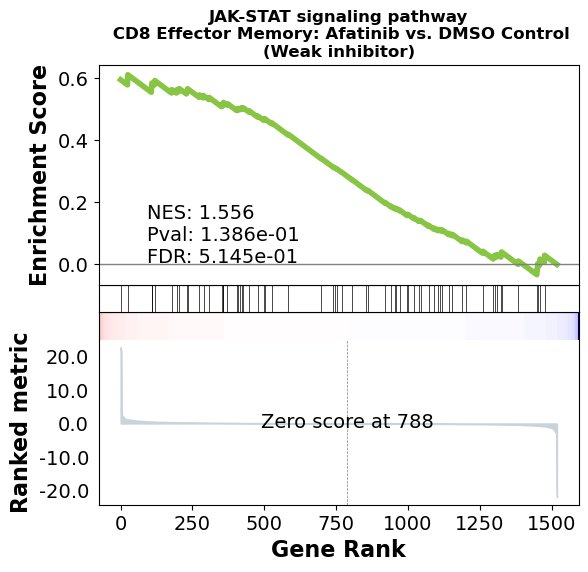

In [37]:
# from gseapy import gseaplot
# gseaplot(rank_metric=pre_res.ranking, 
# term=terms[0], 
# ofname='your.plot.pdf', 
# **pre_res.results[terms[0]])

from gseapy import gseaplot

for cell_type, drug, label in comparisons:

    pre_res = gsea_res[cell_type][drug]
    
    axs = gseaplot(
        rank_metric=pre_res.ranking,
        term=pathway,
        **pre_res.results[pathway]
    )

    # Remove the default gseaplot title!
    axs[0].set_title("")

    # Get the figure object
    fig = axs[0].get_figure()

    # Add a visible figure-level title
    fig.suptitle(
        f"{pathway}\n {cell_type}: {drug} vs. DMSO Control {label}",
        fontsize=12,
        fontweight="bold",
        y=1.00
    )

## Other multi-pathway visualizations:

**To answer: Which KEGG pathways are upregulated in this cluster? Which KEGG pathways are dowregulated in this cluster? Change the pathway source to another gene set (MsigDB Hallmark, Reactome...) and check the if we get similar results?**

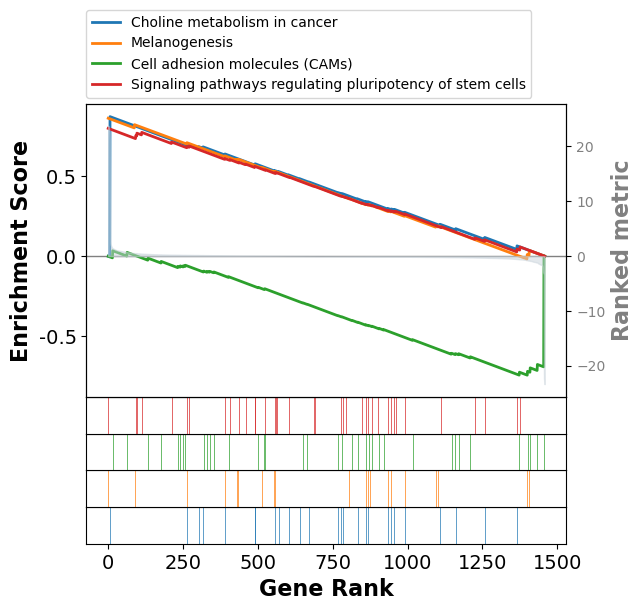

In [63]:
axs = pre_res.plot(terms=terms[1:5],
                   #legend_kws={'loc': (1.2, 0)}, # set the legend loc
                   show_ranking=True, # whether to show the second yaxis
                   figsize=(3,4)
                  )
# or use this to have more control on the plot
# from gseapy import gseaplot2
# terms = pre_res.res2d.Term[1:5]
# hits = [pre_res.results[t]['hits'] for t in terms]
# runes = [pre_res.results[t]['RES'] for t in terms]
# fig = gseaplot2(terms=terms, ress=runes, hits=hits,
#               rank_metric=gs_res.ranking,
#               legend_kws={'loc': (1.2, 0)}, # set the legend loc
#               figsize=(4,5)) # rank_metric=pre_res.ranking

**To do: Which KEGG pathways are upregulated in this cluster? Which KEGG pathways are dowregulated in this cluster? Change the pathway source to another gene set (MsigDB Hallmark, Reactome...) and check the if we get similar results?**

## dotplot for GSEA results:

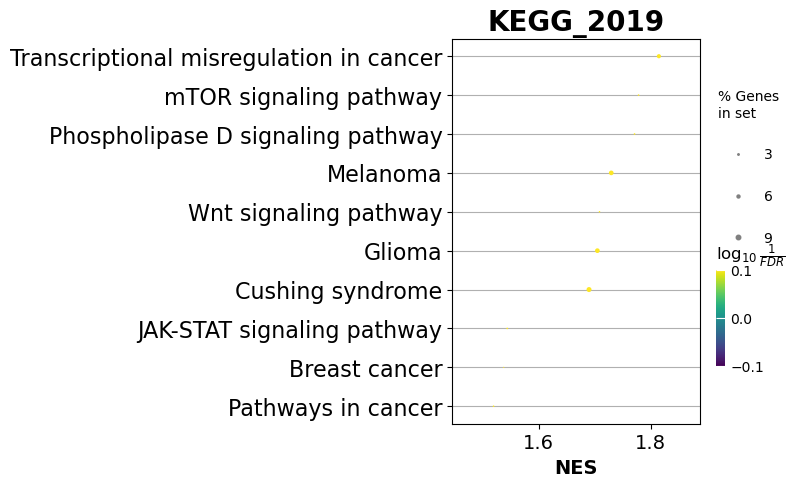

In [66]:
# to save your figure, make sure that ``ofname`` is not None
ax = dotplot(pre_res.res2d,
             column="FDR q-val",
             title='KEGG_2019',
             cmap=plt.cm.viridis,
             size=6, # adjust dot size
             figsize=(4,5), cutoff = 1) # cutoff value: terms with column value < cut-off are shown. Work only for (“Adjusted P-value”, “P-value”, “NOM p-val”, “FDR q-val”)
# https://www.biostars.org/p/209118/
# 

**To do: This may be helpful for a single comparison (like a treatment with one drug within one cell type)!**

## Network visualization:

- use `enrichment_map` to build network
- save the `nodes` and `edges`. They could be used for `cytoscape` visualization.

In [ ]:
from gseapy import enrichment_map
# return two dataframes
nodes, edges = enrichment_map(pre_res.res2d)

# seems like this set didn't have anything for default cutoffs = 0.05, set it higher in enrichment_map() 

In [ ]:
import networkx as nx

In [ ]:
# build graph
G = nx.from_pandas_edgelist(edges,
                            source='src_idx',
                            target='targ_idx',
                            edge_attr=['jaccard_coef', 'overlap_coef', 'overlap_genes'])

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# init node cooridnates
pos=nx.layout.spiral_layout(G)
#node_size = nx.get_node_attributes()
# draw node
nx.draw_networkx_nodes(G,
                       pos=pos,
                       cmap=plt.cm.RdYlBu,
                       node_color=list(nodes.NES),
                       node_size=list(nodes.Hits_ratio *1000))
# draw node label
nx.draw_networkx_labels(G,
                        pos=pos,
                        labels=nodes.Term.to_dict())
# draw edge
edge_weight = nx.get_edge_attributes(G, 'jaccard_coef').values()
nx.draw_networkx_edges(G,
                       pos=pos,
                       width=list(map(lambda x: x*10, edge_weight)),
                       edge_color='#CDDBD4')
plt.show()